In [143]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Any
from langchain_groq import ChatGroq

from dotenv import load_dotenv

load_dotenv()  # Load environment variables from .env file
import os
from pydantic import BaseModel, Field

import operator

In [144]:
llm = ChatGroq( model= "openai/gpt-oss-120b" , api_key= os.getenv("GROQ_API_KEY"))

In [145]:
# Define the state graph


# 1. essay store 
# 2. COT feedback
# 3. Dept of analysis feedback
# 4. evalution feedback
# 5. final essay store

# individual score []
# final_avarage of score float

In [146]:
class EvalutionSchema(BaseModel):
    feedback: str = Field(description="Feedback on the essay")
    score: float = Field(description="Score given to the essay", ge=0, le=10)
    

In [147]:
structured_model = llm.with_structured_output(EvalutionSchema)

In [148]:
essay = '''In Python, inheritance means creating a new class by using the features of an existing class. In Pydantic, `BaseModel` is a parent class that provides useful features such as data validation, type checking, and JSON conversion. When we write `class User(BaseModel)`, the `User` class inherits these features from `BaseModel`. We can then define fields such as `name: str` and `age: int`, and Pydantic checks whether the provided data matches the expected structure and data types. This makes `BaseModel` very useful when working with APIs, LLM structured outputs, and applications where data should follow a fixed format.
'''

In [149]:
prompt = f"evaluate the following essay and provide feedback and a score out of 10:\n\n{essay}"

structured_model.invoke(prompt).score

7.5

In [150]:
structured_model.invoke(prompt).feedback

'The essay gives a concise and accurate description of inheritance in Python and how Pydantic’s `BaseModel` leverages it. It correctly explains that `User` inherits validation, type‑checking, and JSON conversion capabilities, and it mentions practical use‑cases (APIs, LLM outputs, fixed‑format data). The writing is clear, well‑structured, and free of major factual errors. \n\nAreas for improvement:\n1. Depth: The piece could expand on how `BaseModel` performs validation (e.g., automatic parsing, error messages) and mention optional features like model configuration or custom validators.\n2. Examples: Including a short code snippet showing a validation failure or JSON export would illustrate the concepts more concretely.\n3. Context: Briefly contrasting inheritance with composition or mentioning when you might not want to inherit from `BaseModel` would show broader understanding.\n4. Minor style: Adding a concluding sentence that ties the benefits back to why developers choose Pydantic 

In [151]:
# define a state

class EssayState(TypedDict):
    essay: str
    language: str
    COT_feedback: str
    dept_feedback: str
    evaluation_feedback: str
    final_essay: str
    
    individual_scores: Annotated[list[float], operator.add]
    
    


In [152]:
def language_generator(state: EssayState):
    prompt = f"Evaluate the language quality of the following essay and give the score out of 10:\n\n{state['essay']}"
    output = structured_model.invoke(prompt)
    
    return {
        "language": output.feedback,
        "individual_scores": [output.score]
    }
    

In [153]:
def cot_feedback_generator(state: EssayState):
    prompt = f"Evaluate the COT quality of the following essay and give the score out of 10:\n\n{state['essay']}"
    output = structured_model.invoke(prompt)
    
    return {
        "COT_feedback": output.feedback,
        "individual_scores": [output.score]
    }
    

In [154]:
def dept_feedback_generator(state: EssayState):
    prompt = f"Evaluate the dept or analysis quality of the following essay and give the score out of 10:\n\n{state['essay']}"
    output = structured_model.invoke(prompt)
    
    return {
        "dept_feedback": output.feedback,
        "individual_scores": [output.score]
    }
    

In [155]:
def final_essay_generator(state: EssayState):
    prompt = f"based on the following feedback create a summarized feedback \n language: {state['language']}\n COT_feedbackk: {state['COT_feedback']}\n dept feedback: {state['dept_feedback']}"
    final_feedback = llm.invoke(prompt)
    
    average_score = sum(state['individual_scores']) / len(state['individual_scores']) 
    
    return {
        "final_essay": final_feedback,
        "individual_scores": [average_score]  # Placeholder, replace with actual scores if available
    }
    

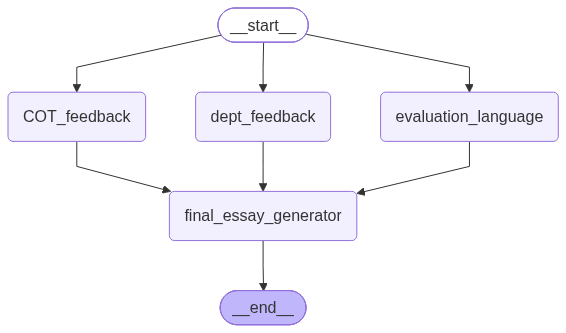

In [156]:
graph = StateGraph(EssayState)


# define a node

graph.add_node("evaluation_language" , language_generator)
graph.add_node("COT_feedback" , cot_feedback_generator)
graph.add_node("dept_feedback" , dept_feedback_generator)
graph.add_node("final_essay_generator" , final_essay_generator)




# define a edge


graph.add_edge(START, "evaluation_language")
graph.add_edge(START, "COT_feedback")
graph.add_edge(START, "dept_feedback")

graph.add_edge("evaluation_language", "final_essay_generator")
graph.add_edge("COT_feedback", "final_essay_generator")
graph.add_edge("dept_feedback", "final_essay_generator")

graph.add_edge("final_essay_generator", END)









# compile the graph

graph.compile()



In [157]:
workflow = graph.compile()


# run the graph

initial_state = {
    "essay": '''Prajyot Mulik’s career journey is built on continuous learning, struggle, and improvement. Starting from a computer science background, he gradually developed strong interest in Python, Generative AI, RAG, LangGraph, FastAPI, and Agentic AI. He entered the IT industry as an AI/GenAI Engineer at Genpact, where he worked on enterprise AI solutions, migration assessment, multi-agent workflows, structured outputs, validation, and automation. Along the way, he faced many technical errors, deployment issues, and learning gaps, but each problem helped him understand engineering more deeply. Today, his goal is to become a strong AI Engineer, move into a higher-paying role, and eventually build his own AI products for students and job seekers. His journey is still in progress, but the pattern is clear: learn, build, fail, improve, and keep moving forward.'''
}


workflow.invoke(initial_state)


{'essay': 'Prajyot Mulik’s career journey is built on continuous learning, struggle, and improvement. Starting from a computer science background, he gradually developed strong interest in Python, Generative AI, RAG, LangGraph, FastAPI, and Agentic AI. He entered the IT industry as an AI/GenAI Engineer at Genpact, where he worked on enterprise AI solutions, migration assessment, multi-agent workflows, structured outputs, validation, and automation. Along the way, he faced many technical errors, deployment issues, and learning gaps, but each problem helped him understand engineering more deeply. Today, his goal is to become a strong AI Engineer, move into a higher-paying role, and eventually build his own AI products for students and job seekers. His journey is still in progress, but the pattern is clear: learn, build, fail, improve, and keep moving forward.',
 'language': 'The essay is clear and well‑structured, presenting a coherent narrative of Prajyot Mulik’s professional developmen